# Analyzing Popularity Patterns in Your Data



This notebook provides practical patterns for understanding popularity dynamics in implicit-feedback recommendation data.



## What you will do

1. Analyze popularity distribution in MovieLens 100K.

2. Compare popularity across time windows.

3. Reuse a generic popularity-analysis template for your own dataset.

4. Explore an optional synthetic fashion example with seasonal effects.



## 1. MovieLens Example

We inspect long-tail behavior, identify the most popular items, and compare how item popularity changes over time.



## 2. Template for Your Data

You will get reusable functions and guiding questions for adapting this analysis to any interaction table.



In [20]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



from pathlib import Path


sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)


def locate_ml100k() -> Path:

    """Find a local MovieLens 100K folder without requiring a download."""

    candidates = [

        Path("notebooks/data/ml-100k"),

        Path("../data/ml-100k"),

        Path("../../notebooks/data/ml-100k"),

        Path("data/ml-100k"),

    ]

    for path in candidates:

        if (path / "u.data").exists() and (path / "u.item").exists():

            return path

    raise FileNotFoundError(

        "Could not find MovieLens 100K data. Expected u.data and u.item in a local data folder."

    )



def print_basic_popularity_summary(df: pd.DataFrame, user_col: str, item_col: str) -> pd.Series:

    """Compute and print core popularity statistics."""

    counts = df.groupby(item_col).size().rename("interaction_count")

    print(f"Users: {df[user_col].nunique():,}")

    print(f"Items: {df[item_col].nunique():,}")

    print(f"Interactions: {len(df):,}")

    print("\nPopularity distribution summary:")

    print(counts.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())

    return counts


## 1) MovieLens Example: Popularity Distribution



This section analyzes the long-tail shape of movie interactions and highlights how concentrated demand is across items.


In [21]:
ml100k_path = locate_ml100k()

print(f"Using MovieLens data at: {ml100k_path}")



ratings = pd.read_csv(

    ml100k_path / "u.data",

    sep="\t",

    names=["userId", "movieId", "rating", "timestamp"],

)



# Keep only the most recent 365 days to simulate a realistic recency-focused analysis window.

ratings["event_time"] = pd.to_datetime(ratings["timestamp"], unit="s")

max_event_time = ratings["event_time"].max()

window_start = max_event_time - pd.Timedelta(days=365)

ratings = ratings[ratings["event_time"] >= window_start].copy()

print(f"Analyzing last-year window: {window_start.date()} to {max_event_time.date()}")

print(f"Interactions kept: {len(ratings):,}")



movies = pd.read_csv(

    ml100k_path / "u.item",

    sep="|",

    encoding="latin-1",

    names=[

        "movieId", "title", "release_date", "video_release_date", "IMDb_URL",

        "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",

        "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",

        "Romance", "Sci-Fi", "Thriller", "War", "Western",

    ],

    usecols=["movieId", "title"],

)



item_popularity = print_basic_popularity_summary(ratings, user_col="userId", item_col="movieId")



movie_stats = (

    item_popularity.reset_index()

    .rename(columns={"movieId": "movieId", "interaction_count": "interaction_count"})

    .merge(movies, on="movieId", how="left")

    .sort_values("interaction_count", ascending=False)

)



print("\nTop 10 most popular movies:")

display(movie_stats.head(10))


Using MovieLens data at: notebooks/data/ml-100k
Analyzing last-year window: 1997-04-22 to 1998-04-22
Interactions kept: 100,000
Users: 943
Items: 1,682
Interactions: 100,000

Popularity distribution summary:
count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
50%        27.000000
90%       169.000000
95%       229.850000
99%       369.090000
max       583.000000

Top 10 most popular movies:


,movieId,interaction_count,title
49,50,583,Star Wars (1977)
257,258,509,Contact (1997)
99,100,508,Fargo (1996)
180,181,507,Return of the Jedi (1983)
293,294,485,Liar Liar (1997)
285,286,481,"English Patient, The (1996)"
287,288,478,Scream (1996)
0,1,452,Toy Story (1995)
299,300,431,Air Force One (1997)
120,121,429,Independence Day (ID4) (1996)


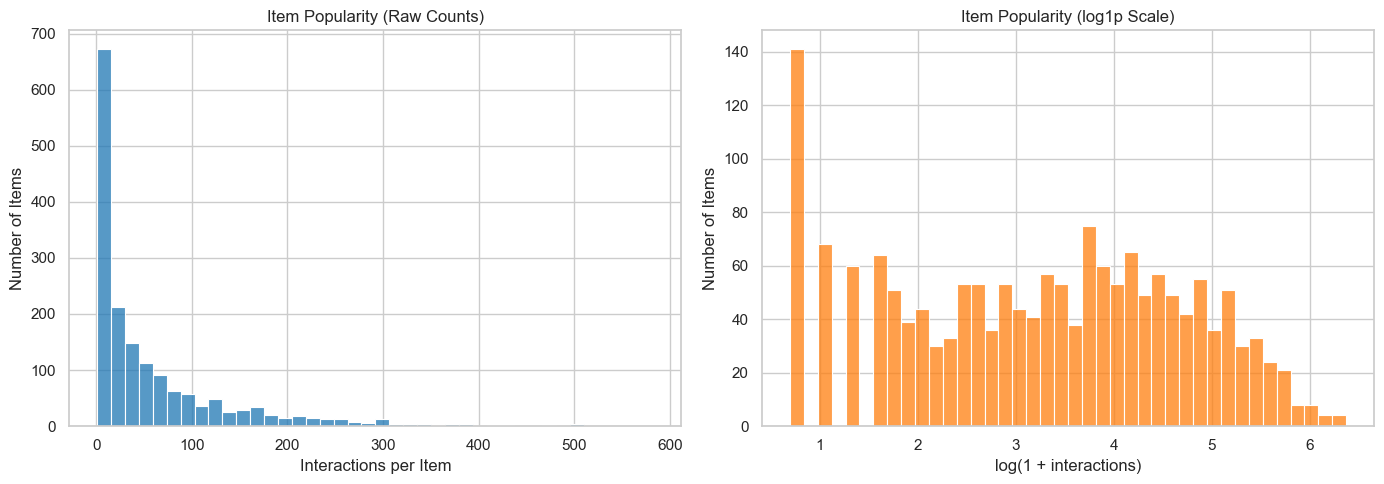

Share of interactions from top-1 item: 0.58%
Share of interactions from top-10 items: 4.86%


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))



sns.histplot(item_popularity, bins=40, ax=axes[0], color="#1f77b4")

axes[0].set_title("Item Popularity (Raw Counts)")

axes[0].set_xlabel("Interactions per Item")

axes[0].set_ylabel("Number of Items")



sns.histplot(np.log1p(item_popularity), bins=40, ax=axes[1], color="#ff7f0e")

axes[1].set_title("Item Popularity (log1p Scale)")

axes[1].set_xlabel("log(1 + interactions)")

axes[1].set_ylabel("Number of Items")



plt.tight_layout()

plt.show()



share_top_1 = item_popularity.sort_values(ascending=False).head(1).sum() / item_popularity.sum()

share_top_10 = item_popularity.sort_values(ascending=False).head(10).sum() / item_popularity.sum()

print(f"Share of interactions from top-1 item: {share_top_1:.2%}")

print(f"Share of interactions from top-10 items: {share_top_10:.2%}")


Median split time: 1997-12-22 21:42:24

Top 10 movies with biggest upward popularity shift:


,movieId,early_count,late_count,title,change
311,313,3,347,Titanic (1997),344
1466,272,0,198,Good Will Hunting (1997),198
727,751,5,175,Tomorrow Never Dies (1997),170
1468,315,0,160,Apt Pupil (1998),160
1473,347,0,137,Wag the Dog (1997),137
1472,346,0,126,Jackie Brown (1997),126
726,750,1,123,Amistad (1997),122
1469,316,0,112,As Good As It Gets (1997),112
867,895,3,103,Scream 2 (1997),100
298,300,168,263,Air Force One (1997),95


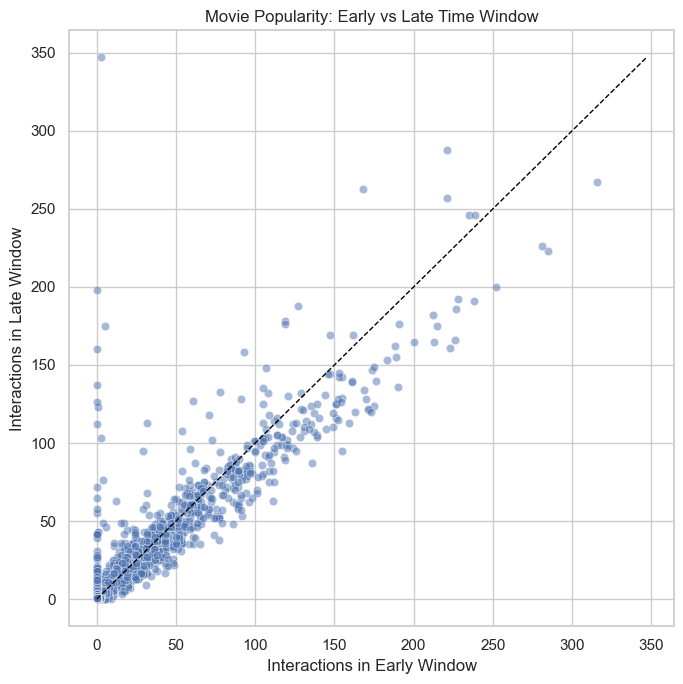

In [23]:
ratings_with_time = ratings.copy()

ratings_with_time["event_time"] = pd.to_datetime(ratings_with_time["timestamp"], unit="s")


split_time = ratings_with_time["event_time"].median()

early = ratings_with_time[ratings_with_time["event_time"] <= split_time]

late = ratings_with_time[ratings_with_time["event_time"] > split_time]



early_pop = early.groupby("movieId").size().rename("early_count")

late_pop = late.groupby("movieId").size().rename("late_count")



temporal_compare = (

    pd.concat([early_pop, late_pop], axis=1)

    .fillna(0)

    .astype(int)

    .merge(movies, on="movieId", how="left")

)

temporal_compare["change"] = temporal_compare["late_count"] - temporal_compare["early_count"]



print(f"Median split time: {split_time}")

print("\nTop 10 movies with biggest upward popularity shift:")

display(temporal_compare.sort_values("change", ascending=False).head(10))



plt.figure(figsize=(7, 7))

sns.scatterplot(data=temporal_compare, x="early_count", y="late_count", alpha=0.5)

max_count = int(max(temporal_compare["early_count"].max(), temporal_compare["late_count"].max()))

plt.plot([0, max_count], [0, max_count], linestyle="--", color="black", linewidth=1)

plt.title("Movie Popularity: Early vs Late Time Window")

plt.xlabel("Interactions in Early Window")

plt.ylabel("Interactions in Late Window")

plt.tight_layout()

plt.show()


## 2) Template for Your Data



Use this section for your own interaction table. Replace column names and pass your dataframe into the helper.


Basic dataset summary
----------------------------------------
Users: 943
Items: 1,682
Interactions: 100,000
count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
50%        27.000000
90%       169.000000
95%       229.850000
99%       369.090000
max       583.000000


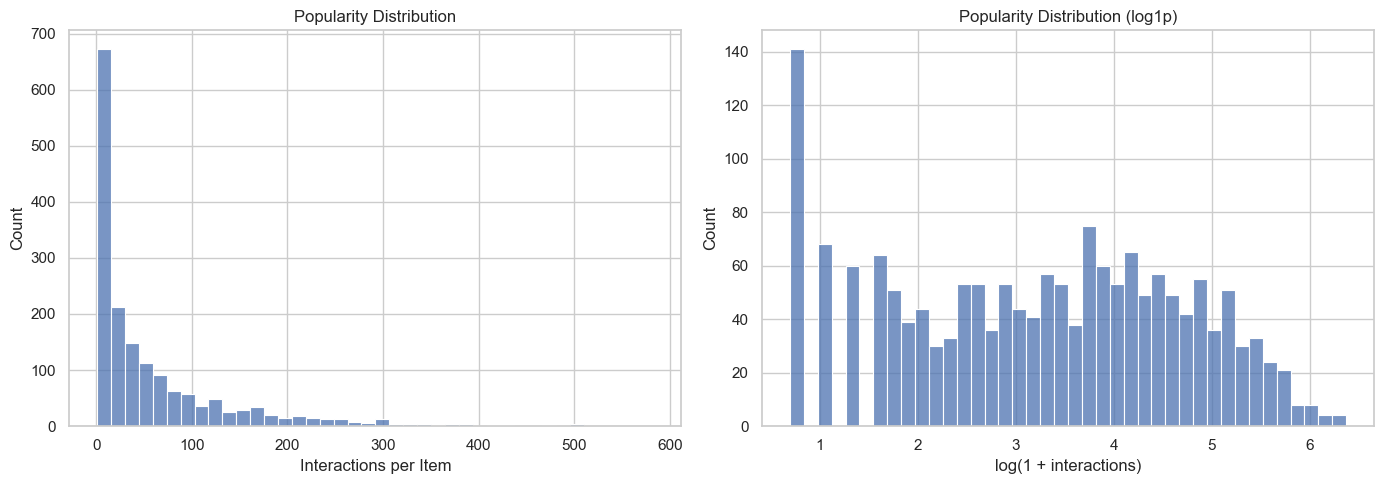

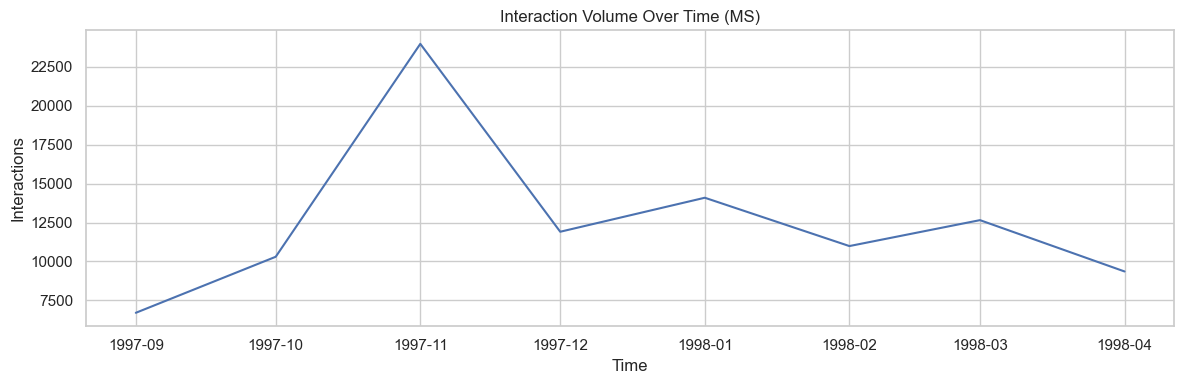


Top-10 items by interactions:


,interaction_count
movieId,
50,583
258,509
100,508
181,507
294,485
286,481
288,478
1,452
300,431


In [24]:
def analyze_popularity_template(

    interactions: pd.DataFrame,

    user_col: str,

    item_col: str,

    ts_col: str | None = None,

    freq: str = "MS",

    top_k: int = 10,

) -> dict[str, pd.DataFrame | pd.Series]:

    """Reusable popularity diagnostics for arbitrary interaction data."""

    required = {user_col, item_col}

    missing = required - set(interactions.columns)

    if missing:

        raise ValueError(f"Missing required columns: {sorted(missing)}")



    out = {}

    popularity = interactions.groupby(item_col).size().rename("interaction_count").sort_values(ascending=False)

    out["popularity"] = popularity



    print("Basic dataset summary")

    print("-" * 40)

    print(f"Users: {interactions[user_col].nunique():,}")

    print(f"Items: {interactions[item_col].nunique():,}")

    print(f"Interactions: {len(interactions):,}")

    print(popularity.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())



    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(popularity, bins=40, ax=axes[0])

    axes[0].set_title("Popularity Distribution")

    axes[0].set_xlabel("Interactions per Item")



    sns.histplot(np.log1p(popularity), bins=40, ax=axes[1])

    axes[1].set_title("Popularity Distribution (log1p)")

    axes[1].set_xlabel("log(1 + interactions)")

    plt.tight_layout()

    plt.show()



    if ts_col is not None:

        if ts_col not in interactions.columns:

            raise ValueError(f"Timestamp column '{ts_col}' not found")

        tmp = interactions.copy()

        tmp[ts_col] = pd.to_datetime(tmp[ts_col], errors="coerce")

        tmp = tmp.dropna(subset=[ts_col])

        time_series = tmp.set_index(ts_col).resample(freq)[item_col].count().rename("interaction_count")

        out["time_series"] = time_series



        plt.figure(figsize=(12, 4))

        sns.lineplot(x=time_series.index, y=time_series.values)

        plt.title(f"Interaction Volume Over Time ({freq})")

        plt.xlabel("Time")

        plt.ylabel("Interactions")

        plt.tight_layout()

        plt.show()



    print(f"\nTop-{top_k} items by interactions:")

    display(popularity.head(top_k).to_frame())

    return out



# Example reuse with MovieLens data

_ = analyze_popularity_template(

    interactions=ratings_with_time,

    user_col="userId",

    item_col="movieId",

    ts_col="event_time",

    freq="MS",

    top_k=10,

)


### Questions to ask about your data



- How concentrated are interactions in the head (top-1, top-10, top-1%)?

- Is concentration stable over time, or does it increase/decrease?

- Which items are rising or fading fastest between adjacent windows?

- Are there seasonal effects (weekend, monthly, holiday, weather, campaign-driven)?

- Should your candidate-generation stage cap exposure to very popular items?

- Should your ranking stage include popularity debiasing or freshness features?
